# Nagumo observation comparison

Compare observation histories from the coarse and fine simulations. The fine solution is sampled at the coarse time steps and used as the reference for relative $L^2$ errors.

In [9]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

# Support running this notebook from either the repository root or Nagumo/.
cwd = Path.cwd().resolve()
if (cwd / "observations_coarse.npy").is_file() and (cwd / "params.py").is_file():
    data_dir = cwd
elif (cwd / "Nagumo" / "observations_fine.npy").is_file():
    data_dir = cwd / "Nagumo"
else:
    raise FileNotFoundError(
        "Could not find the Nagumo observation files. Run this notebook "
        "from the repository root or the Nagumo directory."
    )

params_spec = spec_from_file_location("nagumo_comparison_params", data_dir / "params.py")
if params_spec is None or params_spec.loader is None:
    raise ImportError(f"Could not load parameters from {data_dir / 'params.py'}")
params = module_from_spec(params_spec)
params_spec.loader.exec_module(params)
T = params.T

observations_coarse = np.load(data_dir / "observations_coarse.npy", allow_pickle=False)
observations_fine = np.load(data_dir / "observations_fine.npy", allow_pickle=False)

print(f"Loaded coarse observations: {observations_coarse.shape}")
print(f"Loaded fine observations:   {observations_fine.shape}")
print(f"Final time: {T:g}")

Loaded coarse observations: (1000, 5)
Loaded fine observations:   (2000, 5)
Final time: 5


In [10]:
for name, values in (
    ("coarse observations", observations_coarse),
    ("fine observations", observations_fine),
):
    if values.ndim != 2:
        raise ValueError(f"{name} must be a 2D array; got shape {values.shape}")
    if not np.isfinite(values).all():
        raise ValueError(f"{name} contains non-finite values")

n_coarse, n_observations = observations_coarse.shape
n_fine, n_fine_observations = observations_fine.shape

if n_fine_observations != n_observations:
    raise ValueError(
        "Observation-column mismatch: "
        f"coarse has {n_observations}, fine has {n_fine_observations}"
    )
if n_fine != 2 * n_coarse:
    raise ValueError(
        "Fine observations must contain exactly twice as many time samples "
        f"as coarse observations; got {n_fine} and {n_coarse}"
    )

track_point_labels = [
    "(0.25, 0.25)",
    "(0.00, 0.50)",
    "(-0.25, 0.50)",
    "(-0.50, 0.25)",
    "(-0.75, 0.00)",
]
if n_observations != len(track_point_labels):
    raise ValueError(
        f"Expected {len(track_point_labels)} observation columns for the known "
        f"track points; got {n_observations}"
    )

In [11]:
# Row i stores the solution after time step i + 1. Therefore coarse row i
# corresponds to fine row 2*i + 1, not fine row 2*i.
observations_fine_aligned = observations_fine[1::2]
times = np.arange(1, n_coarse + 1, dtype=np.float64) * (T / n_coarse)

if observations_fine_aligned.shape != observations_coarse.shape:
    raise RuntimeError(
        "Aligned fine observations do not match the coarse shape: "
        f"{observations_fine_aligned.shape} != {observations_coarse.shape}"
    )

print(f"Aligned comparison shape: {observations_coarse.shape}")
print(f"Coarse time step: {T / n_coarse:g}")

Aligned comparison shape: (1000, 5)
Coarse time step: 0.005


In [12]:
def relative_l2_percent(approximation, reference):
    """Return 100 * ||approximation-reference||_2 / ||reference||_2."""
    difference_norm = np.linalg.norm(approximation - reference)
    reference_norm = np.linalg.norm(reference)
    if reference_norm > 0.0:
        return 100.0 * difference_norm / reference_norm
    return 0.0 if difference_norm == 0.0 else np.inf

relative_errors_percent = np.array([
    relative_l2_percent(
        observations_coarse[:, point_index],
        observations_fine_aligned[:, point_index],
    )
    for point_index in range(n_observations)
])
global_relative_error_percent = relative_l2_percent(
    observations_coarse.ravel(),
    observations_fine_aligned.ravel(),
)

In [13]:
print("Relative L2 errors (fine solution is the reference)")
print(f"{'Observation point':>20}  {'Error (%)':>12}")
print("-" * 35)
for label, error in zip(track_point_labels, relative_errors_percent):
    print(f"{label:>20}  {error:12.6g}")
print("-" * 35)
print(f"{'Global':>20}  {global_relative_error_percent:12.6g}")

Relative L2 errors (fine solution is the reference)
   Observation point     Error (%)
-----------------------------------
        (0.25, 0.25)      0.857009
        (0.00, 0.50)      0.275933
       (-0.25, 0.50)      0.143932
       (-0.50, 0.25)     0.0467164
       (-0.75, 0.00)     0.0544337
-----------------------------------
              Global      0.533583


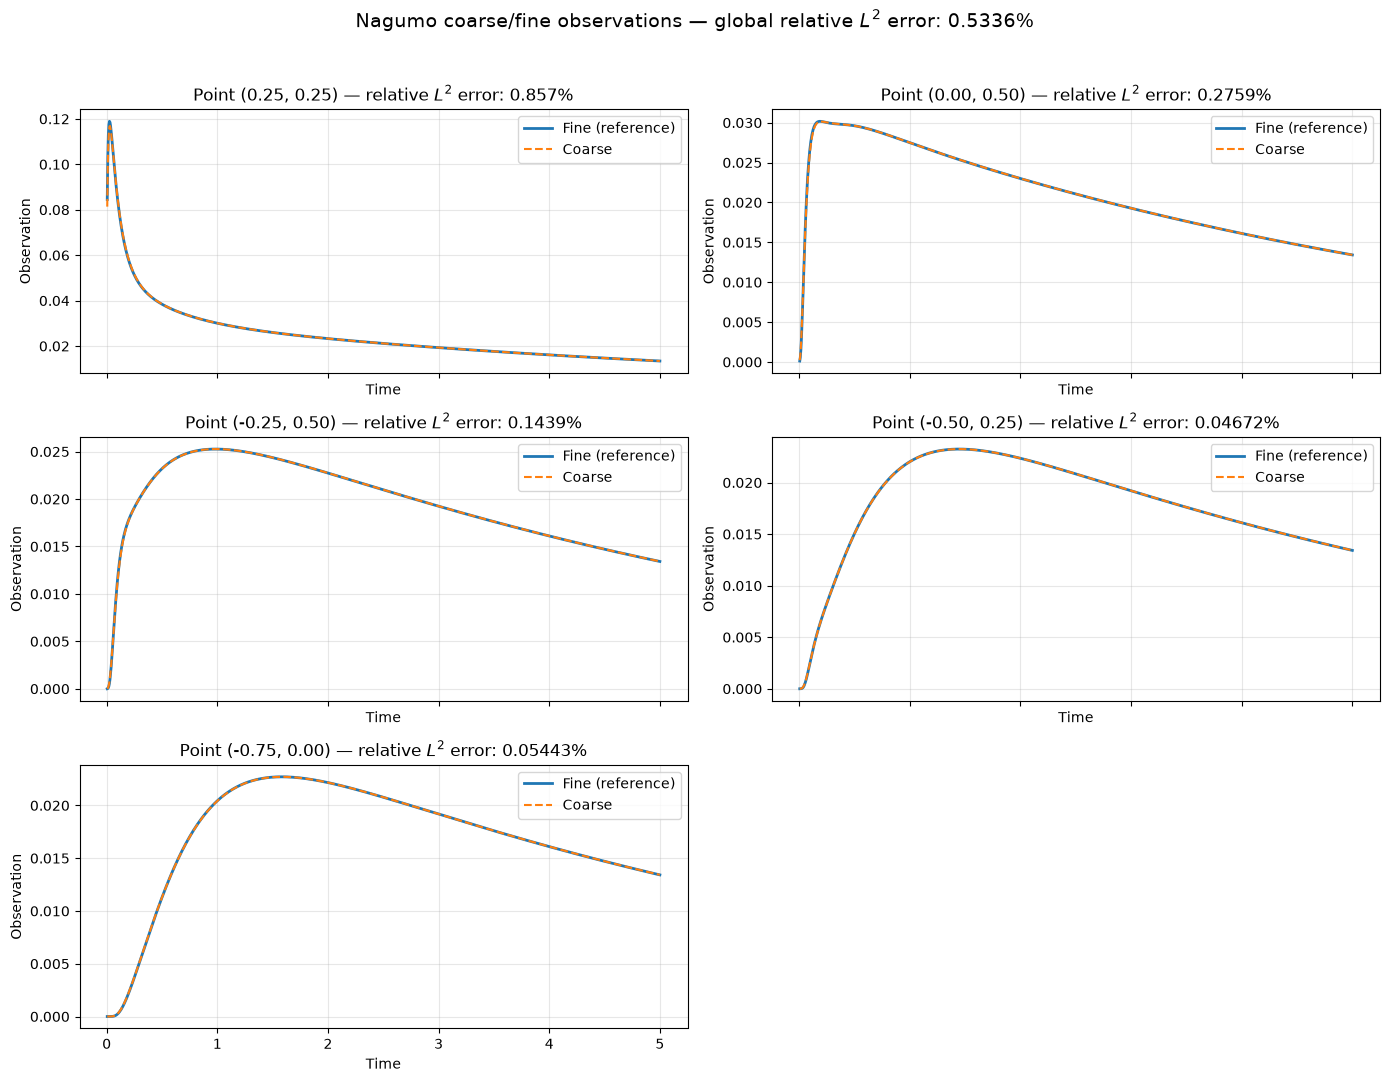

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()

for point_index, (axis, label, error) in enumerate(
    zip(axes, track_point_labels, relative_errors_percent)
):
    axis.plot(
        times,
        observations_fine_aligned[:, point_index],
        label="Fine (reference)",
        color="tab:blue",
        linewidth=2.0,
    )
    axis.plot(
        times,
        observations_coarse[:, point_index],
        label="Coarse",
        color="tab:orange",
        linestyle="--",
        linewidth=1.5,
    )
    axis.set_title(f"Point {label} — relative $L^2$ error: {error:.4g}%")
    axis.set_xlabel("Time")
    axis.set_ylabel("Observation")
    axis.grid(alpha=0.3)
    axis.legend()

fig.delaxes(axes[-1])
fig.suptitle(
    f"Nagumo coarse/fine observations — global relative $L^2$ error: "
    f"{global_relative_error_percent:.4g}%",
    fontsize=14,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.show()